In [1]:
import os
os.chdir("C:\\rthomas\\Pycode\\Run_EchoPop")
#print(os.getcwd())
#Go to parent directory so that rest of this runs

In [2]:
#PLOPPED hake_2015_RT.py code here
####################################################################################################
# 2015
# ----
from pathlib import Path
from echopop.workflow_examples import cli_utils
from echopop import utils
from echopop.utils import feat_functions as feat, feat_parameters as feat_parameters
#from echopop.workflows.nwfsc_feat import functions as feat, parameters as feat_parameters
from echopop.survey import apportionment, biology, proportions, stratified, transect
import echopop.ingest as ingestion
import yaml
from echopop.survey import biology
import logging
import copy
from datetime import date
from typing import Callable
####################################################################################################
# PARAMETER ENTRY
# ---------------
# ** ENTER FILE INFORMATION FOR ALL INGESTED DATASETS.
# ** ADDITIONAL PARAMETERIZATIONS THROUGHOUT THE SCRIPT SHOULD BE EDITED BASED ON SPECIFIC NEEDS. 
# ** MAKE SURE TO EDIT WITH CARE.
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# PRINT CONSOLE LOGGING MESSAGES
# ---- When set to `True`, logging information will be printed in the terminal/console as the 
# ---- script progresses
try: 
    # ---- FOR CLI USE
    VERBOSE = cli_utils.get_verbose()
except Exception:
    # ---- FOR INTERACTIVE REPL USE
    VERBOSE = True
#these are things tha may be brought in by cli_utils. For now define here
Year= 2015
Years=[Year]
runyearstr=str(Year) #added by RT
EXTRAP_FLAG= True #True or False
STRATA_TYPE="ks" #ks or inpfc
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Read in configuration
config_ingest = yaml.safe_load(Path("workflow/workflow_configs_hake"+runyearstr+"/biodata_ingestion.yaml").read_text(encoding="utf-8"))
config_strata = yaml.safe_load(Path("workflow/workflow_configs_hake"+runyearstr+"/stratification.yaml").read_text(encoding="utf-8"))
config_analysis = yaml.safe_load(Path("workflow/workflow_configs_hake"+runyearstr+"/biodata_analysis.yaml").read_text(encoding="utf-8"))
config_kriging = yaml.safe_load(Path("workflow/workflow_configs_hake"+runyearstr+"/kriging_config.yaml").read_text(encoding="utf-8"))
config_nasc = yaml.safe_load(Path("workflow/workflow_configs_hake"+runyearstr+"/nasc_config.yaml").read_text(encoding="utf-8"))
config_output = yaml.safe_load(Path("workflow/workflow_configs_hake"+runyearstr+"/output_config.yaml").read_text(encoding="utf-8"))


# Root data directory
DATA_ROOT = Path(config_ingest["data_root"])
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# REPORTS SAVE DIRECTORY
if EXTRAP_FLAG==True:
    Exname="KwE"
else:
    Exname="KnE"
REPORTS_DIR = Path(config_output["reports_out_base"]+runyearstr+"/EchoPop/"+STRATA_TYPE+"/"+Exname+"/" )
ECHOPOP_ROOT = lambda year: Path(config_output["reports_out_base"]+f"/{year}/EchoPop/"+STRATA_TYPE+"/"+Exname+"/")

#COMPARISONS_DIR = Path(DATA_ROOT / "comparisons" /runyearstr/ "EchoPop" /STRATA_TYPE/ Exname)  
#COMPARISONS_DIR=config_output["comparison_output_path"]
COMPARISONS_DIR = Path(config_output["comparison_output_path"]  +"/"+runyearstr+"/"+ "EchoPop" +"/"+STRATA_TYPE+"/" +Exname+"/") 
# COMPARE TO ECHOPRO REPORTS?
#for now, since not using CLI, set manuall

try:
    # ---- FOR CLI USE
    COMPARE = cli_utils.get_compare()
    ECHOPRO_REPORTS_DIR = Path("C:/rthomas/Projects/EchoPop_validation/Reports") /runyearstr/ "EchoPro_2022" / STRATA_TYPE / Exname
    ECHOPRO_ROOT = lambda year: Path(f"C:/rthomas/Projects/EchoPop_validation/Reports/{year}/EchoPro_2022/"+STRATA_TYPE+"/"+Exname+"/")
    #ECHOPRO_ROOT = lambda year: Path(f"C:/Data/EchopopData/reports/{year}/echopro")
    #COMPARISONS_DIR = DATA_ROOT / "comparisons"
    #COMPARISONS_DIR = Path(config_output["comparison_output_path"]  +"/"+runyearstr+"/"+ "EchoPop" +"/"+STRATA_TYPE+"/" +Exname+"/") 

    #Set save filepath for figure
    #SAVE_FILEPATH = Path(
    #    DATA_ROOT / "comparisons"/  f"cross_year_comparisons_{date.today().strftime("%Y%m%d")}.png"
    #)


    SHOW_PLOT = False
except Exception:
    # ---- FOR INTERACTIVE REPL USE
    COMPARE = False

COMPARE=True
# REMOVE AGE-1 (I.E., AGE-2+ ONLY)?
REMOVE_AGE1 = True

# ---------------------------
# Stage 1: Biodata ingestion
# ---------------------------

BIODATA_FILE = Path(DATA_ROOT / "biological/updated"  / config_ingest["biodata_file"])

logging.info(
    f"Beginning biodata ingestion for: '{BIODATA_FILE.as_posix()}'."
)

# Biodata file sheetnames
BIODATA_SHEETS = config_ingest["biodata_sheets"]
# Biodata ingestion parameters
RENAME_BIODATA_COLUMNS = config_ingest["rename_biodata_columns"]

# Haul UID reference dictionary
HAUL_UID_CONFIG = {
    "ship_id": {
        "US": config_ingest["biodata_subset"]["ship_us"], 
        "CAN": config_ingest["biodata_subset"]["ship_can"]
    },
    "survey_id": {
        "US": config_ingest["biodata_subset"]["survey_us"], 
        "CAN": config_ingest["biodata_subset"]["survey_can"]
    },
    "species_id": config_ingest["biodata_subset"]["species_id"],
    "haul_offset": config_ingest["biodata_subset"]["can_haul_offset"]
}


# Different biodata processing parameters required for parsing the Excel-formatted dataset
BIODATA_SHIP_SPECIES = {
    "ships": {
        config_ingest["biodata_subset"]["ship_us"]: {
            "country": "US",
            "survey": config_ingest["biodata_subset"]["survey_us"] 
        },
        config_ingest["biodata_subset"]["ship_can"]: {
            "country": "CAN",
            "survey": config_ingest["biodata_subset"]["survey_can"],
            "haul_offset": config_ingest["biodata_subset"]["can_haul_offset"]
        }
    },
    "species_code": [config_ingest["biodata_subset"]["species_id"]]
}
# Biodata ingestion parameters
RENAME_BIODATA_COLUMNS = config_ingest["rename_biodata_columns"]
CAN_HAUL_OFFSET = config_ingest["biodata_subset"]["can_haul_offset"]

# Biodata sex label mapping
BIODATA_SEX = {
    "sex": {
        1: "male",
        2: "female",
        3: "unsexed"
    }
}
# Ingest biodata based on configured typing
#load biodata function looks for a uid column
if config_ingest["biodata_format"] == "excel":
    dict_df_bio = ingestion.load_biological_data(
        biodata_filepath=BIODATA_FILE, 
        biodata_sheet_map=BIODATA_SHEETS, 
        column_name_map=RENAME_BIODATA_COLUMNS, 
        survey_subset=BIODATA_SHIP_SPECIES, 
        biodata_label_map=BIODATA_SEX,
        haul_uid_config=HAUL_UID_CONFIG,
    )
    # Remove specimen-only hauls only when configured
    # ---- ! This is ONLY compatible for when the Excel file format is ingested
#    if config_ingest["drop_specimen_hauls"]:  #probably can be removed
#        biology.drop_specimen_only_hauls(dict_df_bio)
elif config_ingest["biodata_format"] == "views":
    dict_df_bio = ingestion.load_biodata_views(
        biodata_filepaths=BIODATA_FILE,
        column_name_map=RENAME_BIODATA_COLUMNS,
        survey_subset=BIODATA_SHIP_SPECIES, 
        biodata_label_map=BIODATA_SEX,
        haul_uid_config=HAUL_UID_CONFIG,
    )
else:
    raise KeyError(
        f"Configuration parameter 'biodata_format' must be either 'excel' or 'views'. "
        f"Got: '{config_ingest['biodata_format']}'!"
    )


# BIODATA PROCESSING: AGE-1 DOMINATED HAULS
# ---- This is a list of age-1 dominated haul numbers that should be designated for removal. If no
# ---- hauls should be removed, then set `AGE1_DOMINATED_HAULS` to `[]`
AGE1_DOMINATED_HAULS = []
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# HAUL STRATIFICATION FILE
# ------------------------------------
# Stage 2: Stratification + join stage
# ------------------------------------
# Load strata file
logging.info(
    "Loading stratification files..."
)
DATA_STRATA_ROOT = Path(config_strata["data_root"]) /"Stratification" / runyearstr
df_dict_strata = ingestion.load_strata(
    strata_filepath=DATA_STRATA_ROOT / config_strata["strata_file"], 
    strata_sheet_map=config_strata["strata_sheets"], 
    column_name_map=config_strata["rename_strata_columns"],
    haul_uid_config=HAUL_UID_CONFIG,
)
logging.info(
    "Haul-based stratification loading complete\n"
    "'df_dict_strata' created."
)

# Apply strata to biodata
if config_strata["join_method"] == "haul":
    dict_df_bio = ingestion.join_strata_by_haul(
        data=dict_df_bio,
        strata=df_dict_strata[config_strata["stratum_source"]],
        default_stratum=config_strata["default_stratum"],
        stratum_name=config_strata["stratum_name"]
    )
    #uid for consistent indexing, US&CAN hauls; retain haul and ship information
elif config_strata["join_method"] == "uid":
    dict_df_bio = ingestion.join_strata_by_uid(
        data=dict_df_bio,
        strata=df_dict_strata[config_strata["stratum_source"]],
        default_stratum=config_strata["default_stratum"],
        stratum_name=config_strata["stratum_name"]
    )
else:
    raise KeyError(
        f"Configuration parameter 'join_method' must be either 'haul' or 'uid'. "
        f"Got: '{config_strata['biodata_format']}'!"
    )    

# READ IN GEOSTRATA FILE
# GEOGRAPHIC STRATIFICATION FILE
GEOSTRATA_FILE=Path(DATA_STRATA_ROOT) / config_strata["geo_strata_file"]
logging.info(
    f"Load in geographic-based stratification: '{GEOSTRATA_FILE.as_posix()}'."
)

df_dict_geostrata = ingestion.load_geostrata(
    geostrata_filepath=DATA_STRATA_ROOT / config_strata["geo_strata_file"], 
    geostrata_sheet_map=config_strata["geo_strata_sheets"], 
    column_name_map=config_strata["rename_geo_strata_columns"],
)

logging.info(
    "Geographic-based stratification loading complete\n"
    "'df_dict_geostrata' created."
)

### SET DEFAULT STRATA based on STRATA_TYPE
if STRATA_TYPE=="inpfc":
    STRATUM_USE="stratum_inpfc"
    GEOSTRATUM_USE="geostratum_inpfc"
else:
    STRATUM_USE="stratum_ks"
    GEOSTRATUM_USE="geostratum_ks"

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# KRIGING MESH FILE 
KRIGING_MESH_FILE = (
    Path(DATA_ROOT) / "Kriging files & parameters/Kriging Grid Files" / config_kriging["mesh_file"]
)
KRIGING_MESH_SHEET = config_kriging["mesh_sheet"]

############################### CHANGES FOR NON-EXTRAPOLATION ######################################
# KRIGING MESH PROCESSING: CROP METHOD
# ---- This should be a Callable function. When cropping, this typically defaults to using a convex
# ---- hull method. However, custom functions can be called, such as cropping based on the
# ---- interpolated boundaries of the survey region. These custom functions can be found in the
# ---- `FEAT.fun` module.
# KRIGING MESH PROCESSING: CROPPING FUNCTION PARAMETERS
# ---- For the FEAT-specific `transect_ends_crop` function, a transect-region mapping function
# ---- must be provided. These can be year-specific and can be found in the `FEAT.parameters`
# ---- module. This transect mesh region mapping function tracks the original transect region
# ---- definition files used in the MATLAB EchoPro distribution.
if EXTRAP_FLAG==False:
    CROP_METHOD = feat.transect_ends_crop
#TRANSECT_MESH_REGION_MAP = feat_parameters.transect_mesh_region_2019
    TRANSECT_MESH_REGION_MAP_STRING = ("transect_mesh_region_"+runyearstr)
    TRANSECT_MESH_REGION_MAP = getattr(feat_parameters, TRANSECT_MESH_REGION_MAP_STRING)
####################################################################################################

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# KRIGING AND VARIOGRAM PARAMETERS FILE
# KRIGING_VARIOGRAM_PARAMETERS_FILE = (
KRIGING_VARIOGRAM_PARAMETERS_FILE = (
    DATA_ROOT / "Kriging Files & parameters" / runyearstr / config_kriging["variogram_parameters_file"]
)
# KRIGING AND VARIOGRAM PARAMETERS SHEET
KRIGING_VARIOGRAM_PARAMETERS_SHEET = config_kriging["variogram_parameters_sheet"] 
# USE DEFAULT VALUES OR OPTIMIZE?
OPTIMIZE_VARIOGRAM = False
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# # 200m ISOBATH FILE

ISOBATH_FILE = (
    DATA_ROOT / "Kriging files & parameters/Kriging Grid Files" / config_kriging["isobath_file"]
)
# 200m ISOBATH SHEET
ISOBATH_SHEET = config_kriging["isobath_sheet"]


#-----------------------
# Stage 3 : ingest NASC
#-----------------------

#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# ALREADY PROCESSED NASC FILE ? 
# ---- When False, the raw NASC exports will be processed. When True, the pre-formatted NASC 
# ---- spreadsheet will be read in. This also requires defining `NASC_EXPORTS_SHEET`
NASC_PREPROCESSED = False
# NASC EXPORTS FILE(S)
NASC_EXPORTS_FILES = Path(DATA_ROOT) / "Exports/EchoPro_Exports" / config_nasc["formatted_exports_file"]
NASC_EXPORTS_SHEET = config_nasc["formatted_exports_sheet"] #e.g. "Sheet1"
NASC_EXPORTS_PATH =Path(DATA_ROOT) / "Exports"/ runyearstr  # pathfor Echoview exports


ECHOPOP_PATTERNS = {
    "transect": r"^EchoPro_un-kriged_output(?:-.*)?_0\.xlsx$",
    "kriging":  r"^EchoPro_kriged_output(?:-.*)?_0\.xlsx$",
}

ECHOPRO_PATTERNS = {
    "transect": r"^EchoPro_un-kriged_output(?:-.*)?_0\.xlsx$",
    "kriging":  r"^EchoPro_kriged_output(?:-.*)?_0\.xlsx$",
}

####################################################################################################
####################################################################################################
# !!! START OF PROCESSING SCRIPT !!
# !!! EDIT CODE BELOW WITH CARE !!
####################################################################################################
####################################################################################################
import logging
import numpy as np
import xarray as xr
from lmfit import Parameters
from echopop.reports import Reporter, compare
from echopop import geostatistics, inversion, utils
####################################################################################################
# FORMAT LOGGER
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)
    
logging.basicConfig(
    level=logging.INFO if VERBOSE else logging.WARNING,
    format="%(message)s")
# ==================================================================================================
# DATA INGESTION 
# ==================================================================================================

# INGEST NASC DATA 
if NASC_PREPROCESSED:
    logging.info(f"Reading pre-generated NASC export file: '{NASC_EXPORTS_FILES.as_posix()}'.")

    # DEFINE COLUMN MAPPING
    FEAT_TO_ECHOPOP_COLUMNS = {
        "transect": "transect_num",
        "region id": "region_id",
        "vl start": "distance_s",
        "vl end": "distance_e",
        "spacing": "transect_spacing",
        "layer mean depth": "layer_mean_depth",
        "layer height": "layer_height",
        "bottom depth": "bottom_depth",
        "assigned haul": "haul_num",
    }

    # Read file
    df_nasc = ingestion.nasc.read_nasc_file(
        filename=NASC_EXPORTS_FILES,
        sheetname=NASC_EXPORTS_SHEET,
        column_name_map=FEAT_TO_ECHOPOP_COLUMNS,
        haul_uid_config=HAUL_UID_CONFIG,
    )
else:
    logging.info(
        f"Beginning NASC export ingestion for files in: '{NASC_EXPORTS_FILES.as_posix()}'."
    )

    # MERGE EXPORTS
    logging.info(
        "---- Merging NASC exports...\n"
        "     Filename transect pattern: 'T(\\d+)'\n"
        "     Default transect spacing: 10.0 nmi\n"
        "     Default latitude threshold: 60.0 deg."
    )    
    df_intervals, df_exports = ingestion.nasc.merge_echoview_nasc(
        file_directory = NASC_EXPORTS_PATH,
        filename_transect_pattern = r"T(\d+)",
        default_transect_spacing = 10.0,
        default_latitude_threshold = 60.0,
    )

    # EXPORT REGION NAME MAPPING
    REGION_NAME_EXPR_DICT = {
        "REGION_CLASS": {
            "Age-0 Hake": "^(?:h0a(?![a-z]|m))",
            "Age-1 Hake": "^(?:h1a(?![a-z]|m))",
            "Age-1 Hake Mix": "^(?:h1am(?![a-z]|1a))",
            "Hake": "^(?:h(?![a-z]|1a)|hake(?![_]))",
            "Hake Mix": "^(?:hm(?![a-z]|1a)|hake_mix(?![_]))",
        },
        "HAUL_NUM": {
            "[0-9]+",
        },
        "COUNTRY": {
            "CAN": "^[cC]",
            "US": "^[uU]",
        },
    }    
    
    # PROCESS REGION NAMES 
    logging.info(
        f"---- Processing export region names\n"
        f"     Applying CAN haul number offset: {CAN_HAUL_OFFSET}"
    )


    ## >>>> Filter out any class "unknown" from df_exports (RT added)
    # In 2015 on x49 there was a region that was named as a hake mix region, but later changed to unknown.  
    # Regions in EchoPop are filtered by region name, not by class
    rows = df_exports[df_exports["region_class"] == "unknown"].index
    df_exports.drop(rows, inplace=True)

    # >>>> Maybe insert `utils.add_uid` (or equivalent function)
    df_exports_with_regions = ingestion.nasc.process_region_names(
        nasc_cells=df_exports,
        region_name_expr=REGION_NAME_EXPR_DICT,
        can_haul_offset=CAN_HAUL_OFFSET,
    )
    
    # GENERATE TRANSECT-REGION-HAUL KEY
    if REMOVE_AGE1:
        CLASS_REGIONS = ["Hake", "Hake Mix"]
    else:
        CLASS_REGIONS = ["Age-1 Hake", "Age-1 Hake Mix", "Hake", "Hake Mix"]
    logging.info(
        f"---- Generating transect-region-haul key mapping\n"
        f"     Searching for the export regions: {', '.join(CLASS_REGIONS)}"
    )
    df_transect_region_haul_key = ingestion.nasc.generate_transect_region_haul_key(
        region_data=df_exports_with_regions,
        filter_list=CLASS_REGIONS
    )
    
    # AGE-1 DOMINATED HAUL REMOVAL
    if REMOVE_AGE1:
        logging.info(
            f"The following age-1 dominated haul numbers have been designated for removal from "
            f"transect-region-haul key mapping:\n"
            f"{', '.join(map(str, AGE1_DOMINATED_HAULS))}."
        )
        df_transect_region_haul_key = utils.apply_filters(
            df_transect_region_haul_key, exclude_filter={"haul_num": AGE1_DOMINATED_HAULS}
        )

    # CONSOLIDATE THE EXPORTS WITH TRANSECT-REGION-HAUL MAPPINGS
    logging.info(
        "---- Finalizing NASC export ingestion\n"
        "     Searching for the export regions: 'Age-1 Hake', 'Age-1 Hake Mix', 'Hake', 'Hake Mix'"
        "     Imputing overlapping region IDs within each interval: True"
    )
    
    df_nasc = ingestion.nasc.consolidate_echvoiew_nasc(
        nasc_data=df_exports_with_regions,
        interval_data=df_intervals,
        region_class_names=CLASS_REGIONS,
        impute_region_ids=True,
        transect_region_haul_key=df_transect_region_haul_key,
        haul_uid_config=HAUL_UID_CONFIG
    )
    
    # >>>
logging.info(
    "NASC ingestion complete\n"
    "'df_nasc' created."
)

# DROP TRANSECTS
#df_nasc = utils.apply_filters(df_nasc, include_filter={"transect_num": np.arange(1, 2000)})
keepnum=np.arange(1,2000)
elements_to_remove=49 #for testing, get rid of x49
keepnum = keepnum[~np.isin(keepnum, elements_to_remove)]
df_nasc = utils.apply_filters(df_nasc, include_filter={"transect_num": keepnum})
# # ==================================================================================================

# AGE-1 DOMINATED HAUL REMOVAL
if len(AGE1_DOMINATED_HAULS) > 0:
    logging.info(
        f"The following age-1 dominated haul numbers have been designated for removal from "
        f"biodata:\n"
        f"{', '.join(map(str, AGE1_DOMINATED_HAULS))}."
    )
    dict_df_bio = {
        key: utils.apply_filters(dataset, exclude_filter={"haul_num": AGE1_DOMINATED_HAULS})
        for key, dataset in dict_df_bio.items()
    }
    logging.info(
        f"The following age-1 dominated haul numbers were successfully removed from the biodata:\n"
        f"{', '.join(map(str, AGE1_DOMINATED_HAULS))}."
    )

# ==================================================================================================
# LOAD KRIGING MESH FILE
logging.info(
    f"Loading kriging mesh file: '{KRIGING_MESH_FILE.as_posix()}'."
)

# KRIGING MESH DATAFRAME COLUMN NAME MAPPING
FEAT_TO_ECHOPOP_MESH_COLUMNS = {
    "latitude": "latitude",
    "longitude": "longitude",
    "cell portion": "fraction",
}

# LOAD MESH
df_mesh = ingestion.load_mesh_data(
    mesh_filepath=KRIGING_MESH_FILE, 
    sheet_name=KRIGING_MESH_SHEET, 
    column_name_map=FEAT_TO_ECHOPOP_MESH_COLUMNS
)
logging.info(
    "Kriging mesh loading complete\n"
    "'df_mesh' created."
)
# ==================================================================================================
# LOAD ISOBATH FILE
logging.info(
    f"Loading isobath file: '{ISOBATH_FILE}'."
)
df_isobath = ingestion.load_isobath_data(
    isobath_filepath=ISOBATH_FILE,
    sheet_name=ISOBATH_SHEET
)
logging.info(
    f"Iosbath loading complete\n"
    "'df_isobath' created."
)
# ==================================================================================================
# LOAD KRIGING AND VARIOGRAM PARAMETERS
logging.info(
    f"Loading variogram and kriging parameters: '{KRIGING_VARIOGRAM_PARAMETERS_FILE.as_posix()}'."
)

# PARAMETERS DATAFRAME COLUMN NAME MAPPING
FEAT_TO_ECHOPOP_GEOSTATS_PARAMS_COLUMNS = {
    "hole": "hole_effect_range",
    "lscl": "correlation_range",
    "nugt": "nugget",
    "powr": "decay_power",
    "ratio": "aspect_ratio",
    "res": "lag_resolution",
    "srad": "search_radius",
}

# LOAD IN PARAMETERS
dict_kriging_params, dict_variogram_params = ingestion.load_kriging_variogram_params(
    geostatistic_params_filepath=KRIGING_VARIOGRAM_PARAMETERS_FILE,
    sheet_name=KRIGING_VARIOGRAM_PARAMETERS_SHEET,
    column_name_map=FEAT_TO_ECHOPOP_GEOSTATS_PARAMS_COLUMNS
)
logging.info(
    "Variogram and kriging parameter loading complete\n"
    "---- 'dict_variogram_params' created [variogram]\n"
    "---- 'dict_kriging_params' created [kriging]"
)
# ==================================================================================================
# INITIAL DATA PROCESSING
# ==================================================================================================
# APPLY STRATIFICATION DEFINITIONS TO BIODATA AND NASC
logging.info("Applying strata to datasets...")

# HAUL-BASED STRATA
logging.info(
    "Applying haul-based strata to 'dict_df_bio' and 'df_nasc'.\n"
    "     Using column 'uid' as haul-based unique identifier\n"
    "     Default stratum: 0\n"
    "     New columns:\n"
    "         INPFC: 'stratum_inpfc'\n"
    "         KS: 'stratum_ks'"
)
# ---- BIODATA [INPFC]
dict_df_bio = ingestion.join_strata_by_uid(
    data=dict_df_bio,
    strata=df_dict_strata["inpfc"],
    default_stratum=0,
    stratum_name="stratum_inpfc",
)
# ---- BIODATA [KS]
dict_df_bio = ingestion.join_strata_by_uid(
    data=dict_df_bio, strata=df_dict_strata["ks"], default_stratum=0, stratum_name="stratum_ks"
)
# ---- NASC [INPFC]
df_nasc = ingestion.join_strata_by_uid(
    data=df_nasc, strata=df_dict_strata["inpfc"], default_stratum=0, stratum_name="stratum_inpfc"
)
# ---- NASC [KS]
df_nasc = ingestion.join_strata_by_uid(
    data=df_nasc, strata=df_dict_strata["ks"], default_stratum=0, stratum_name="stratum_ks"
)

# GEOGRAPHIC-BASED STRATA
logging.info(
    "Applying geographic-based strata to 'df_nasc' and 'df_mesh.\n"
    "     New columns:\n"
    "         INPFC: 'geostratum_inpfc'\n"
    "         KS: 'geostratum_ks'"
)
# ---- NASC [INPFC]
df_nasc = ingestion.join_geostrata_by_latitude(
    data=df_nasc,
    geostrata=df_dict_geostrata["inpfc"],
    stratum_name="geostratum_inpfc"
)
# ---- NASC [KS]
df_nasc = ingestion.join_geostrata_by_latitude(
    data=df_nasc,
    geostrata=df_dict_geostrata["ks"],
    stratum_name="geostratum_ks"
)
# ---- MESH [INPFC]
df_mesh = ingestion.join_geostrata_by_latitude(
    data=df_mesh, 
    geostrata=df_dict_geostrata["inpfc"], 
    stratum_name="geostratum_inpfc"
)
# ---- MESH [KS]
df_mesh = ingestion.join_geostrata_by_latitude(
    data=df_mesh, 
    geostrata=df_dict_geostrata["ks"], 
    stratum_name="geostratum_ks"
)
logging.info("Strata application complete!")
# ==================================================================================================
# # BINIFY DATA 
# ---------------------------
# Stage 3: Analysis bin setup
# ---------------------------
# Binify data
# --- Age-bins
AGE_BINS = np.linspace(
    start=config_analysis["age"]["start"], 
    stop=config_analysis["age"]["end"], 
    num=config_analysis["age"]["count"]
)
utils.binify(
    data=dict_df_bio, bins=AGE_BINS, bin_column=config_analysis["age"]["column"],
)

# LENGTH-BINS
LENGTH_BINS = np.linspace(
    start=config_analysis["length"]["start"], 
    stop=config_analysis["length"]["end"], 
    num=config_analysis["length"]["count"]
)
utils.binify(
    data=dict_df_bio, bins=LENGTH_BINS, bin_column=config_analysis["length"]["column"], 
)

logging.info("Age and length binning complete!")
# ==================================================================================================
# FIT LENGTH-WEIGHT REGRESSION
logging.info("Fitting length-weight regression for each sex and for all fish.")

# CREATE DICTIONARY CONTAINER
dict_length_weight_coefs = {}

# ALL FISH
dict_length_weight_coefs["all"] = dict_df_bio["specimen"].assign(sex="all").groupby(["sex"]).apply(
    biology.fit_length_weight_regression,
    include_groups=False
)

# SEX-SPECIFIC
dict_length_weight_coefs["sex"] = dict_df_bio["specimen"].groupby(["sex"]).apply(
    biology.fit_length_weight_regression,
    include_groups=False
)
logging.info("Fitting length-weight regression for each sex and for all fish complete!")
# ==================================================================================================
# COMPUTE MEAN WEIGHTS PER LENGTH BIN
logging.info(
    "Computing the mean weight per length bin for each sex and for all fish.\n"
    "     Impute missing length bins using modeled weights: True"
    "     Minimum specimen count per bin: 5"
    )

# SEX-SPECIFIC
da_binned_weights_sex = biology.length_binned_weights(
    data=dict_df_bio["specimen"],
    length_bins=LENGTH_BINS,
    regression_coefficients=dict_length_weight_coefs["sex"],
    impute_bins=True,
    minimum_count_threshold=5
)

# ALL FISH
da_binned_weights_all = biology.length_binned_weights(
    data=dict_df_bio["specimen"].assign(sex="all"),
    length_bins=LENGTH_BINS,
    regression_coefficients=dict_length_weight_coefs["all"],
    impute_bins=True,
    minimum_count_threshold=5,
)

# COMBINE
da_binned_weight_table = xr.concat(
    [da_binned_weights_sex, da_binned_weights_all],
    dim = "sex"
)
# I think below uses specific stratum now (RT)
# ==================================================================================================
# COMPUTE COUNT DISTRIBUTIONS PER AGE- AND LENGTH-BINS

logging.info(
    "Computing the counts per age- and length-bins across sex.\n"
    "     Stratifying by: " + STRATUM_USE+
    "     Grouping by: 'sex'"
    )

# DATASET CONTAINER
ds_counts = xr.Dataset()

# AGED
ds_counts["aged"] = proportions.compute_binned_counts(
    data=dict_df_bio["specimen"].dropna(subset=["age", "length", "weight"]),
    groupby_cols=[STRATUM_USE, "length_bin", "age_bin", "sex"],
    count_col="length",
    agg_func="size",
)

# UNAGED
ds_counts["unaged"] = proportions.compute_binned_counts(
    data=dict_df_bio["length"].copy().dropna(subset=["length"]),
    groupby_cols=[STRATUM_USE, "length_bin", "sex"],
    count_col="length_count",
    agg_func="sum",
)
# ==================================================================================================
# COMPUTE NUMBER PROPORTIONS
logging.info(
    "Computing number proportions across age and length bins\n"
    "     Stratifying by: " + STRATUM_USE+ "\n"
    "     Excluding: 'sex'='unsexed' from 'dict_df_counts['aged']'"
    )
dict_ds_number_proportion = proportions.number_proportions(
    data=ds_counts,
    stratum_dim=STRATUM_USE,
    exclude_filters={"aged": {"sex": "unsexed"}},
)
logging.info(
    "Number proportions calculation complete\n"
    "'dict_df_number_proportions' created\n"
    )
# ==================================================================================================
# COMPUTE BINNED WEIGHTS
logging.info(
    "Computing the summed weights per age- and length-bins across sex.\n"
    "     Stratifying by: " + STRATUM_USE+
    "     Grouping by: 'sex'"
    "     Excluding: 'sex'='unsexed'"
    )

# DATASET CONTAINER
ds_da_weight_dist = xr.Dataset()

# AGED
ds_da_weight_dist["aged"] = proportions.binned_weights(
    length_data=dict_df_bio["specimen"],
    include_filter={"sex": ["female", "male"]},
    interpolate_regression=False,
    group_columns=[STRATUM_USE, "sex", "age_bin"],
)

# UNAGED
logging.info(
    "Unaged binned weights require additional processing steps.\n"
    "     Interpolating binned length-weight regression estimates: True"
    )
ds_da_weight_dist["unaged"] = proportions.binned_weights(
    length_data=dict_df_bio["length"],
    include_filter={"sex": ["female", "male"]},
    interpolate_regression=True,
    length_weight_data=da_binned_weight_table,
    group_columns=[STRATUM_USE, "sex"],
)
# ==================================================================================================
# COMPUTE WEIGHT PROPORTIONS
logging.info(
    "Computing weight proportions across age and length bins\n"
    "     Stratifying by: " + STRATUM_USE+
    "     Grouping by: 'sex'"
    )

# DATAARRAY CONTAINER
dict_da_weight_proportion = {}

# AGED WEIGHT PROPORTIONS
logging.info("Computing aged weight proportions...")
dict_da_weight_proportion["aged"] = proportions.weight_proportions(
    weight_data=ds_da_weight_dist["aged"], 
    catch_data=dict_df_bio["catch"], 
    stratum_dim = STRATUM_USE,
)

# UNAGED WEIGHT PROPORTIONS
logging.info(
    "Computing unaged weight proportions\n"
    "     Scaling weight proportions in reference to the aged estimates"
    )
dict_da_weight_proportion["unaged"] = proportions.fitted_weight_proportions(
    weight_data=ds_da_weight_dist["unaged"],
    aged_weight_proportions=dict_da_weight_proportion["aged"],
    number_proportions=dict_ds_number_proportion["unaged"],
    binned_weights=da_binned_weights_all,
    stratum_dim = STRATUM_USE,
)

# ==================================================================================================
# NASC TO BIOMASS CONVERSION
# ==================================================================================================
# INVERSION
logging.info(
    "Beginning inversion based on hake-specific TS-length regression coefficients\n"
    "     Model: 20.0 x log[10](L) + -68.0\n"
    "     Stratifying by: " + STRATUM_USE+"\n"
    "     Imputing missing strata: True\n"
    "     Treating hauls as replicates: True"
    )

# DEFINE INVERSION MODEL PARAMETERS
MODEL_PARAMETERS = {
    "ts_length_regression": {
        "slope": 20.,
        "intercept": -68.
    },
    #"stratify_by": ["stratum_ks"],
    "stratify_by": [STRATUM_USE],
    "expected_strata": np.sort(df_dict_strata[STRATA_TYPE].stratum_num.unique()),
    "impute_missing_strata": True,
    "haul_replicates": True,
    "haul_column": "uid",
}

# INITIALIZE INVERSION OBJECT
invert_hake = inversion.InversionLengthTS(MODEL_PARAMETERS)
logging.info("Inversion-class object 'invert_hake' created...")

# INVERT NUMBER DENSITY
df_nasc = invert_hake.invert(
    nasc_data=df_nasc, length_data=[dict_df_bio["length"], dict_df_bio["specimen"]]
)
logging.info(
    "Number density inversion complete\n"
    "     New column in 'df_nasc':\n"
    "         Number density (animals nm^-2): 'number_density'"
    )
# ==================================================================================================
# CONVERT TO BIOMASS
logging.info("Converting number density estimates into biomass estimates")

# SET TRANSECT INTERVAL DISTANCES
logging.info(
    "Defining transect interval distances...\n"
    "     Along-transect interval distance (nmi) threshold: 0.5 nmi"
)
transect.compute_interval_distance(nasc_data=df_nasc, interval_threshold=0.05)

# SET TRANSECT INTERVAL AREAS
logging.info("Defining transect interval areas...")
df_nasc["area_interval"] = (
    df_nasc["transect_spacing"] * df_nasc["distance_interval"]
)

# COMPUTE ABUNDANCE
logging.info(
    "Compute interval abundances...\n"
    "     Stratifying by: " + STRATUM_USE+"\n"
    "     Grouping by: 'sex'\n"
    "     Excluding: 'sex'='unsexed' from 'dict_df_number_proportions'"    
)
biology.compute_abundance(
    transect_data=df_nasc,
    exclude_filter={"sex": "unsexed"},
    number_proportions=dict_ds_number_proportion,
)

# COMPUTE STRATUM-AVERAGED WEIGHTS
da_averaged_weight = proportions.stratum_averaged_weight(
    number_proportions=dict_ds_number_proportion,
    length_weight_data=da_binned_weight_table,
    stratum_dim=STRATUM_USE,
)


# COMPUTE BIOMASS
logging.info(
    "Compute interval biomass...\n"
    "     Stratifying by: " + STRATUM_USE+"\n"
    "     Grouping by: 'sex'\n"  
)
biology.compute_biomass(
    transect_data=df_nasc,
    stratum_weights=da_averaged_weight,
)

# AGE-1 CONTRIBUTION REMOVAL
if REMOVE_AGE1:
    logging.info(
        "Removing age-1 contributions from NASC, abundance, and biomass estimates...\n"
    "     Stratifying by: " + STRATUM_USE+"\n"
        "     Minimum length threshold for weight proportions: 10.0 cm\n"
        "     Minimum weight proportion threshold: 1E-10"
    )

    # NASC
    age1_nasc_proportions = proportions.get_nasc_proportions_slice(
        number_proportions=dict_ds_number_proportion["aged"],
        stratum_dim=STRATUM_USE,
        ts_length_regression_parameters={"slope": 20.0, "intercept": -68.0},
        include_filter={"age_bin": [1]},
    )

    # NUMBER
    age1_number_proportions = proportions.get_number_proportions_slice(
        number_proportions=dict_ds_number_proportion["aged"],
        stratum_dim=STRATUM_USE,
        include_filter={"age_bin": [1]},
    )

    # WEIGHT
    age1_weight_proportions = proportions.get_weight_proportions_slice(
        weight_proportions=dict_da_weight_proportion["aged"],
        stratum_dim=STRATUM_USE,
        include_filter={"age_bin": [1]},
        number_proportions=dict_ds_number_proportion,
        length_threshold_min=10.0,
        weight_proportion_threshold=1e-10,
    )

    # APPLY REMOVAL
    df_nasc_proc = apportionment.remove_group_from_estimates(
        transect_data=df_nasc,
        group_proportions=xr.Dataset({
            "nasc": age1_nasc_proportions,
            "abundance": age1_number_proportions,
            "biomass": age1_weight_proportions,
        }),
    )
    logging.info("Age-1 contribution removal complete\n" "'df_nasc_proc' created.")
else:
    df_nasc_proc = df_nasc.copy()
logging.info(
    "NASC to biomass conversion complete\n"
    "     New columns in 'df_nasc':\n"
    "         Sex-specific number densities (animals nmi^-2): "
    "'number_density_female'/'number_density_male'\n"
    "         Abundance (animals): 'abundance'/'abundance_female'/'abundance_male'\n"
    "         Biomass density (kg nmi^-2): 'biomass_density'/'biomass_density_female'/"
    "'biomass_density_male'\n"
    "         Biomass (kg): 'biomass'/'biomass_female'/'biomass_male'"
    )
# SUMMARIZE TRANSECT RESULTS
logging.info(
    f"----------------------\n"
    f"Transect-based results\n"
    f"     Total NASC: {df_nasc_proc['nasc'].sum():.1f} m²nmi⁻²\n"
    f"     Mean number density: {df_nasc_proc['number_density'].mean():.1f} animals nmi⁻²\n"
    f"     Total abundance: {df_nasc_proc['abundance'].sum():.0f} fish\n"
    f"     Mean biomass density: {df_nasc_proc['biomass_density'].mean() * 1e-6:.3f} kmt nmi⁻²\n"
    f"     Total biomass: {df_nasc_proc['biomass'].sum() * 1e-6:.1f} kmt"
)
# ==================================================================================================
# DISTRIBUTE POPULATION ESTIMATES ACROSS AGE AND LENGTH BINS
logging.info(
    "Distribute population estimates across age- and length-bins\n"
    "     Stratifying by: " + STRATUM_USE+"\n"
    "     Grouping by: 'sex'"
)

# ABUNDANCE
logging.info("Distributing abundances...")
dict_ds_transect_abundance_table = apportionment.distribute_population_estimates(
    data = df_nasc,
    proportions = dict_ds_number_proportion,
    variable = "abundance",
    group_columns = ["sex", "age_bin", "length_bin", STRATUM_USE]
)

logging.info("Abundance distributions complete\n'dict_ds_transect_abundance_table' created.")
# BIOMASS [ALL]
logging.info("Distributing biomass...")
dict_ds_transect_biomass_table = apportionment.distribute_population_estimates(
    data=df_nasc,
    proportions=dict_da_weight_proportion,
    variable = "biomass",
    group_columns = ["sex", "age_bin", "length_bin", STRATUM_USE]
)

dict_ds_transect_biomass_table[
    "standardized_unaged"
] = apportionment.distribute_unaged_from_aged(
    population_table = dict_ds_transect_biomass_table["unaged"],
    reference_table = dict_ds_transect_biomass_table["aged"],
    stratum_dim = STRATUM_USE,
    impute = True,
    impute_variable = ['age_bin'],
)

da_transect_biomass_table = apportionment.sum_population_tables(
    population_tables={
        "aged": dict_ds_transect_biomass_table["aged"],
        "unaged": dict_ds_transect_biomass_table["standardized_unaged"]
    },
)

logging.info("Biomass distribution complete\n'dict_ds_transect_biomass_table' created.")
# BIOMASS [AGED-ONLY]
logging.info("Distributing biomass...\n     Aged-only weight proportions: True")
df_transect_aged_biomass_table = apportionment.distribute_population_estimates(
    data=df_nasc_proc,
    proportions=dict_da_weight_proportion["aged"],
    variable="biomass",
    group_columns = ["sex", "age_bin", "length_bin", STRATUM_USE]
)
# ==================================================================================================
# GEOSTATISTICS
# ==================================================================================================
# INITIAL
logging.info("Beginning geostatistical analysis...")
# ==================================================================================================
# COORDINATE TRANSFORMATION
logging.info(
    "Transform spatial coordinates for 'df_nasc' and 'df_mesh'\n"
    "     Reference coordinates: 'df_isobath'\n"
    "     Longitudinal offset: -124.78338 deg.E\n"
    "     Latitudinal offset: 45.0 deg.N"
)

# NASC
df_nasc_proc, delta_longitude, delta_latitude = geostatistics.transform_coordinates(
    data = df_nasc_proc,
    reference = df_isobath,
    x_offset = -124.78338,
    y_offset = 45.,   
)


# MESH
df_mesh, _, _ = geostatistics.transform_coordinates(
    data = df_mesh,
    reference = df_isobath,
    x_offset = -124.78338,
    y_offset = 45.,   
    delta_x=delta_longitude,
    delta_y=delta_latitude
)
logging.info(
    "Coordinate transformation complete\n"
    "     New columns:\n"
    "          Transformed longitude: 'x'\n"
    "          Transformed latitude: 'y'\n"
)
# ==================================================================================================
# VARIOGRAM ANALYSIS
if OPTIMIZE_VARIOGRAM:
    logging.info(
        "Beginning variogram analysis\n"
        "     Normalized lag resolution: 0.002\n"
        "     Number of lags: 30\n"
    )

    # INITIALIZE VARIOGRAM-CLASS OBJECT
    vgm = geostatistics.Variogram(
        lag_resolution=0.002,
        n_lags=30,
        coordinate_names=("x", "y"),
    )
    logging.info("Variogram-class object 'vgm' created...")

    # EMPIRICAL VARIOGRAM
    logging.info(
        "Computing the empirical variogram\n"
        "     Variable: 'biomass_density'\n"
        "     Applying azimuth angle filter: True\n"
        "     Azimuth angle filter: 180.0 deg.\n"
    )
    vgm.calculate_empirical_variogram(
        data=df_nasc_proc,
        variable="biomass_density",
        azimuth_filter=True,
        azimuth_angle_threshold=180.,
    )

    # SET UP FITTING PARAMETERS
    # ----- lmfit.Parameters tuples: (NAME VALUE VARY MIN  MAX  EXPR  BRUTE_STEP)
    logging.info(
        f"Optimizing variogram parameters using non-linear least-squares\n"
        f"     Model: Exponential-Bessel (['exponential', 'bessel'])\n"
        f"     Initial values:\n"
        f"          Nugget: {dict_variogram_params["nugget"]}\n"
        f"          Sill: {dict_variogram_params["sill"]}\n"
        f"          Correlation range: {dict_variogram_params["correlation_range"]}\n"
        f"          Hole effect range: {dict_variogram_params["hole_effect_range"]}\n"
        f"          Decay power exponent: {dict_variogram_params["decay_power"]}"
    )
    variogram_parameters_lmfit = Parameters()
    variogram_parameters_lmfit.add_many(
        ("nugget", dict_variogram_params["nugget"], True, 0.),
        ("sill", dict_variogram_params["sill"], True, 0.),
        ("correlation_range", dict_variogram_params["correlation_range"], True, 0.),
        ("hole_effect_range", dict_variogram_params["hole_effect_range"], True, 0.),
        ("decay_power", dict_variogram_params["decay_power"], True, 1.25, 1.75),
    )

    # OPTIMIZATION PARAMETERS
    OPTIM_ARGS = {
        "max_nfev": None, "ftol": 1e-08, "gtol": 1e-8, "xtol": 1e-8, "diff_step": None, 
        "tr_solver": "exact", "x_scale": 1., "jac": "2-point"
    }
    logging.info(
        f"Optimization arguments:\n"
        f"{OPTIM_ARGS}"
    )

    # RUN MINIMIZER
    best_fit_parameters = vgm.fit_variogram_model(
        model=["exponential", "bessel"],
        model_parameters=variogram_parameters_lmfit,
        optimizer_kwargs=OPTIM_ARGS,
    )
    logging.info(
        f"Variogram parameter fitting complete\n"
        f"     Best-fit parameters:\n"
        f"     {best_fit_parameters}"
    )
else:
    best_fit_parameters = {
        "nugget": dict_variogram_params["nugget"],
        "sill": dict_variogram_params["sill"],
        "hole_effect_range": dict_variogram_params["hole_effect_range"],
        "correlation_range": dict_variogram_params["correlation_range"],
        "decay_power": dict_variogram_params["decay_power"]
    }
# ==================================================================================================
# KRIGING ANALYSIS
logging.info(
    f"Beginning kriging analysis\n"
    f"     Using best-fit variogram model and parameters: True\n"
    f"     Kriging parameters:\n"
    f"          Normalized search radius: {best_fit_parameters["correlation_range"] * 3}\n"
    f"          Minimum nearest-neighbor count: 3\n"
    f"          Maximum nearest-neighbor count: 10\n"
    f"          Anisotropic aspect ratio: 0.001"
)

# KRIGING PARAMETERS CONTAINER
KRIGING_PARAMETERS = {
    "search_radius": best_fit_parameters["correlation_range"] * 3,
    "aspect_ratio": 0.001,
    "k_min": 3,
    "k_max": 10,
}  

# VARIOGRAM PARAMETERS CONTAINER
VARIOGRAM_PARAMETERS = {
    "model": ["exponential", "bessel"],
    "sill": dict_variogram_params["sill"],
    "nugget": dict_variogram_params["nugget"],
    "correlation_range": dict_variogram_params["correlation_range"],
    "hole_effect_range": dict_variogram_params["hole_effect_range"],
    "decay_power": dict_variogram_params["decay_power"],
    **best_fit_parameters
}

# INITIALIZE CLASS OBJECT
krg = geostatistics.Kriging(
    mesh=df_mesh,
    kriging_params=KRIGING_PARAMETERS,
    variogram_params=VARIOGRAM_PARAMETERS,
    coordinate_names=("x", "y"),
)
logging.info("Kriging-class object 'krg' created...")

# REGISTER KRIGING METHOD
krg.register_search_strategy("FEAT_strategy", feat.western_boundary_search_strategy)
# ---- Parameterize
logging.info("Custom nearest neighbor search strategy registered by 'krg' as 'FEAT_strategy'.")
# ---- Define keyword arguments
transect_western_extents = feat.get_survey_western_extents(
    transects=df_nasc_proc, coordinate_names=("x", "y"), latitude_threshold=51.0
)
FEAT_STRATEGY_KWARGS = {
    "western_extent": transect_western_extents,
}

# RUN KRIGING

############################### CHANGES FOR NON-EXTRAPOLATION ######################################
# ---- Crop mesh
if EXTRAP_FLAG==True:
    logging.info(
        "Interpolating population estimates using ordinary kriging\n"
        "     Variable: 'biomass_density'\n"
        "     Extrapolation (full mesh): True\n"
        "     Default mesh cell area: 6.25 nmi^2\n"
    )
else:
    krg.crop_mesh(
        crop_function=CROP_METHOD,
        transects=df_nasc,
        latitude_resolution=1.25 / 60.0,
        transect_mesh_region_function=TRANSECT_MESH_REGION_MAP,
    )

    # ---- Register the custom search strategy
    krg.register_search_strategy("FEAT_strategy", feat.western_boundary_search_strategy)
    logging.info("Custom nearest neighbor search strategy registered by 'krg' as 'FEAT_strategy'.\n"
    "Interpolating population estimates using ordinary kriging\n"
    "     Variable: 'biomass_density'\n"
    "     Extrapolation (full mesh): True\n"
    "     Default mesh cell area: 6.25 nmi^2\n"
    )

#########################

df_kriged_results = krg.krige(
    transects=df_nasc_proc,
    variable="biomass_density",
    extrapolate=EXTRAP_FLAG,
    default_mesh_cell_area=6.25,
    adaptive_search_strategy="FEAT_strategy",
    custom_search_kwargs=FEAT_STRATEGY_KWARGS
)
logging.info(
    f"Kriging complete\n"
    f"'df_kriged_results' created.\n"
    f"Global survey CV: {krg.survey_cv:.3f}"
)

# ==================================================================================================
# CONVERT BIOMASS DENSITY TO NASC
logging.info(
    "Converting biomass density estimates into NASC\n"
#    "     Stratifying by: 'geostratum_ks'/'stratum_ks'\n"
    "     Stratifying by: "+GEOSTRATUM_USE+"/"+STRATUM_USE+'\n'
    "     Grouping by: 'sex'\n"
    "     Using stratum weights for all fish: True"
)

# CONVERT TO BIOMASS
df_kriged_results["biomass"] = df_kriged_results["biomass_density"] * df_kriged_results["area"]
logging.info("New column in 'df_kriged_results': 'biomass'")

# BIOMASS TO NASC
apportionment.mesh_biomass_to_nasc(
    mesh_data=df_kriged_results,
    biodata=dict_da_weight_proportion,
    group_columns=["sex", STRATUM_USE],
    mesh_biodata_link={GEOSTRATUM_USE: STRATUM_USE},
    stratum_weights=da_averaged_weight.sel(sex="all"),
    stratum_sigma_bs=invert_hake.sigma_bs_strata,  
)
logging.info(
    "Biomass density to NASC conversion complete\n"
    "    New columns in `df_kriged_results`\n"
    "        Biomass (kg): 'biomass'/'biomass_female'/'biomass_male'\n"
    "        Abundance (animals): 'abundance'/'abundance_female'/'abundance_male'\n"
    "        NASC (m^2 nmi^-2): 'nasc'"
)

# SUMMARIZE KRIGING RESULTS
logging.info(
    f"----------------------\n"
    f"Kriging-based results\n"
    f"     Total derived NASC: {df_kriged_results['nasc'].sum():.1f} m²nmi⁻²\n"
    f"     Total derived abundance: {df_kriged_results['abundance'].sum():.0f} fish\n"
    f"     Total biomass: {df_kriged_results['biomass'].sum() * 1e-6:.1f} kmt"
)
# ==================================================================================================
# DISTRIBUTE POPULATION ESTIMATES ACROSS AGE AND LENGTH BINS
logging.info(
    "Distribute kriged population estimates across age- and length-bins\n"
    "     Stratifying by: " +STRATUM_USE+"\n"
    "     Grouping by: 'sex'"
)

# ABUNDANCE [ALL]
logging.info("Distributing abundances...")
dict_ds_kriged_abundance_table = apportionment.distribute_population_estimates(
    data=df_kriged_results,
    proportions = dict_ds_number_proportion,
    variable = "abundance",
    group_columns = ["sex", "age_bin", "length_bin", STRATUM_USE],
    data_proportions_link={GEOSTRATUM_USE: STRATUM_USE}
)
logging.info("Abundance distributions complete\n'dict_kriged_abundance_table' created.")

# SCALE UNAGED ABUNDANCE
logging.info(
    "Scaling unaged abundance...\n"     
    "     Reference: Aged abundances\n"
    "     Imputing missing bins: False"
)
dict_ds_kriged_abundance_table["standardized_unaged"] = apportionment.distribute_unaged_from_aged(
    population_table = dict_ds_kriged_abundance_table["unaged"],
    reference_table = dict_ds_kriged_abundance_table["aged"],
    stratum_dim = STRATUM_USE,
    impute = False 
)

# BIOMASS [ALL]
logging.info("Distributing biomass...")
dict_ds_kriged_biomass_table = apportionment.distribute_population_estimates(
    data = df_kriged_results,
    proportions = dict_da_weight_proportion,
    variable = "biomass",
    group_columns = ["sex", "age_bin", "length_bin", STRATUM_USE],
    data_proportions_link={GEOSTRATUM_USE: STRATUM_USE}
)
logging.info("Biomass distribution complete\n'dict_kriged_biomass_table' created.")

# SCALE UNAGED BIOMASS
logging.info(
    "Scaling unaged biomass...\n"     
    "     Reference: Aged biomass\n"
    "     Imputing missing bins: True"
)
dict_ds_kriged_biomass_table["standardized_unaged"] = apportionment.distribute_unaged_from_aged(
    population_table = dict_ds_kriged_biomass_table["unaged"],
    reference_table = dict_ds_kriged_biomass_table["aged"],
    stratum_dim = STRATUM_USE,
    impute=True,
    impute_variable=["age_bin"],
)

# CONSOLIDATE
# ---- ABUNDANCE
logging.info("Consolidating abundance tables...")
da_kriged_abundance_table = apportionment.sum_population_tables(
    population_tables={
        "aged": dict_ds_kriged_abundance_table["aged"],
        "unaged": dict_ds_kriged_abundance_table["standardized_unaged"]
    },
)
logging.info("Abundance table complete\n'df_kriged_abundance_table' created.")
# ---- Biomass
logging.info("Consolidating biomass tables...")
da_kriged_biomass_table = apportionment.sum_population_tables(
    population_tables={
        "aged": dict_ds_kriged_biomass_table["aged"],
        "unaged": dict_ds_kriged_biomass_table["standardized_unaged"]
    },
)
logging.info("Biomass table complete\n'df_kriged_biomass_table' created.")

# AGE-1 REALLOCATION ?
if REMOVE_AGE1:
    # REDISTRIBUTE AGE-1 ABUNDANCES
    logging.info("Redistributing kriged age-1 abundances and biomasses...")
    da_kriged_abundance_table_proc = apportionment.reallocate_excluded_estimates(
        population_table=da_kriged_abundance_table,
        exclusion_filter={"age_bin": [1]},
        group_columns=["sex"],
    )

    # REDISTRIBTUE AGE-1 BIOMASS
    da_kriged_biomass_table_proc = apportionment.reallocate_excluded_estimates(
        population_table=da_kriged_biomass_table,
        exclusion_filter={"age_bin": [1]},
        group_columns=["sex"],
    )
    logging.info(
        "Kriged age-1 abundance and biomass estimates redistributed\n"
        "'da_kriged_abundance_table_proc' and 'da_kriged_biomass_table_proc' created."
    )
    
    # UPDATED KRIGED ABUNDANCE WHEN REDISTRIBUTED
    # ---- Redistribute JUST the aged 
    da_kriged_abundance_table_aged = apportionment.reallocate_excluded_estimates(
        population_table=dict_ds_kriged_abundance_table["aged"],
        exclusion_filter={"age_bin": [1]},
        group_columns=["sex"],
    )
    # ---- Construct dictionary of tables   
    dict_ds_kriged_abundance_table_proc = {
        "aged": da_kriged_abundance_table_aged,
        "unaged": dict_ds_kriged_abundance_table["unaged"],
    }    
else:
    da_kriged_abundance_table_proc = da_kriged_abundance_table
    da_kriged_biomass_table_proc = da_kriged_biomass_table
    dict_ds_kriged_abundance_table_proc = copy.deepcopy(dict_ds_kriged_abundance_table)

# ==================================================================================================
# JOLLY AND HAMPTON (1990) ANALYSIS
# ==================================================================================================
logging.info("Beginning stratified analysis to estimate uncertainties (Jolly and Hampton, 1990)...")

# ANALYSIS PARAMETERS CONTAINER
JOLLYHAMPTON_PARAMETERS = {
    "transects_per_latitude": 5,
    "strata_transect_proportion": 0.75,
    "num_replicates": 1000,
}

# INITIALIZE JOLLYHAMPTON CLASS OBJECT
jh = stratified.JollyHampton(JOLLYHAMPTON_PARAMETERS)
logging.info("Stratified-analysis-class object 'jh' created...")

# RUN ON TRANSECT DATA
logging.info(
    "Running Jolly and Hampton (1990) algorithm for transect data\n"
    "     Variable: 'biomass'\n"
    "     Number of bootstrap replicates: 1000\n"
    "     Stratum transect sampling proportion: 0.75\n"
    "     Stratifying by: 'geostratum_ks'"
)
jh.stratified_bootstrap(data=df_nasc_proc, 
                        stratum_dim="geostratum_inpfc", 
                        variable="biomass")
logging.info(
    "Summarizing results....\n"
    "     Confindence interval percentile: 0.95\n"
    "     Confidence interval method: Jackknife studentized interval ('t-jackknife')"
)
df_jh_transect_results = jh.summarize(ci_percentile=0.95, ci_method="t-jackknife")
logging.info("Stratified transect analysis results complete\n'df_jh_transect_results' created.")

# REPORT
logging.info(
    f"Mean transect CV [95% CI]: "
    f"{df_jh_transect_results.loc[('survey', 'cv')]['mean']:.3f} "
    f"[{df_jh_transect_results.loc[('survey', 'cv')]['low']:.3f}, "
    f"{df_jh_transect_results.loc[('survey', 'cv')]['high']:.3f}]\n"
    f"    Resampling/bootstrapping bias: "
    f"{df_jh_transect_results.loc[('survey', 'cv')]['bias']:.3f}"
)

# RUN ON KRIGED DATA
# ---- Create virtual transects
logging.info(
    "Creating virtual transects for kriged mesh data\n"
    "     Stratifying by: 'geostratum_inpfc'\n"
    "     Virtual transects per latitude: 5"
)
kriged_transects = jh.create_virtual_transects(
    mesh_data=df_kriged_results,
    geostrata=df_dict_geostrata["inpfc"], 
    stratum_dim="geostratum_inpfc",
    variable="biomass",
)
# ---- Run rest of flow
logging.info(
    "Running Jolly and Hampton (1990) algorithm for kriged data\n"
    "     Variable: 'biomass'\n"
    "     Number of bootstrap replicates: 1000\n"
    "     Virtual transect sampling proportion: 0.75\n"
    "     Stratifying by: "+GEOSTRATUM_USE
)
jh.stratified_bootstrap(data=kriged_transects, 
                        stratum_dim="geostratum_inpfc", #for the moment, keep as is.
                        variable="biomass")
logging.info(
    "Summarizing results....\n"
    "     Confindence interval percentile: 0.95\n"
    "     Confidence interval method: Jackknife studentized interval ('t-jackknife')"
)
df_jh_kriged_results = jh.summarize(ci_percentile=0.95, ci_method="t-jackknife")
logging.info("Stratified kriged analysis results complete\n'df_jh_kriged_results' created.")

# REPORT
logging.info(
    f"Mean kriging CV [95% CI]: "
    f"{df_jh_kriged_results.loc[('survey', 'cv')]['mean']:.3f} "
    f"[{df_jh_kriged_results.loc[('survey', 'cv')]['low']:.3f}, "
    f"{df_jh_kriged_results.loc[('survey', 'cv')]['high']:.3f}]\n"
    f"    Resampling/bootstrapping bias: "
    f"{df_jh_kriged_results.loc[('survey', 'cv')]['bias']:.3f}"
)

# ==================================================================================================
# REPORT GENERATION
# ==================================================================================================
logging.info(
    f"Writing reports to: '{REPORTS_DIR.as_posix()}'."
)
reporter = Reporter(REPORTS_DIR, verbose=VERBOSE)


# AGED-LENGTH HAUL
reporter.aged_length_haul_counts_report(
    #filename="aged_length_haul_counts.xlsx",
    filename=config_output["aged_length_haul_counts"],
    sheetnames={"male": "Sheet1", "female": "Sheet2", "all": "Sheet3"},
    bio_data=dict_df_bio["specimen"].dropna(subset=["age", "length", "weight"])
)

# TOTAL LENGTH HAUL COUNTS
reporter.total_length_haul_counts_report(
    #filename="total_length_haul_counts.xlsx",
    filename=config_output["total_length_haul_counts"],
    sheetnames={"male": "Sheet1", "female": "Sheet2", "all": "Sheet3"},
    bio_data=dict_df_bio
)

# KRIGED AGED BIOMASS

# All values
reporter.kriged_aged_biomass_mesh_report(
    #filename="kriged_aged_biomass_mesh_full.xlsx",
    filename=config_output["kriged_aged_biomass_mesh_full"],
    sheetnames={"all": "Sheet1", "male": "Sheet2", "female": "Sheet3"},
    kriged_data=df_kriged_results,
    weight_data=ds_da_weight_dist["aged"],
    kriged_stratum_link={GEOSTRATUM_USE: STRATUM_USE},
)

# Nonzero values
reporter.kriged_aged_biomass_mesh_report(
    #filename="kriged_aged_biomass_mesh_nonzero.xlsx",
    filename=config_output["kriged_aged_biomass_mesh_nonzero"],
    sheetnames={"all": "Sheet1", "male": "Sheet2", "female": "Sheet3"},
    kriged_data=df_kriged_results[df_kriged_results["biomass"] > 0.],
    weight_data=ds_da_weight_dist["aged"],
    kriged_stratum_link={GEOSTRATUM_USE: STRATUM_USE},
)

# KRIGERD MESH RESULTS

# All values
reporter.kriged_mesh_results_report(
    #filename="kriged_biomass_mesh_full.xlsx",
    filename=config_output["kriged_biomass_mesh_full"],
    sheetname="Sheet1",
    kriged_data=df_kriged_results,
    kriged_stratum=GEOSTRATUM_USE,
    kriged_variable="biomass",
    sigma_bs_data=invert_hake.sigma_bs_strata,
    sigma_bs_stratum=STRATUM_USE,
)

# Nonzero values
reporter.kriged_mesh_results_report(
    #filename="kriged_biomass_mesh_nonzero.xlsx",
    filename=config_output["kriged_biomass_mesh_nonzero"], 
    sheetname="Sheet1",
    kriged_data=df_kriged_results[df_kriged_results["abundance"] > 0.],
    kriged_stratum=GEOSTRATUM_USE,
    kriged_variable="biomass",
    sigma_bs_data=invert_hake.sigma_bs_strata,
    sigma_bs_stratum=STRATUM_USE,
)

# KRIGED LENGTH-AGE ABUNDANCES
reporter.kriged_length_age_abundance_report(
    #filename="kriged_length_age_abundance_report.xlsx",
    filename=config_output["kriged_length_age_abundance_report"],
    sheetnames={"male": "Sheet1", "female": "Sheet2", "all": "Sheet3"},
    datatables=dict_ds_kriged_abundance_table_proc,
)

# KRIGED LENGTH-AGE BIOMASS
reporter.kriged_length_age_biomass_report(
    #filename="kriged_length_age_biomass_report.xlsx",
    filename=config_output["kriged_length_age_biomass_report"],
    sheetnames={"male": "Sheet1", "female": "Sheet2", "all": "Sheet3"},
    datatable=da_kriged_biomass_table_proc,
)

# KRIGING INPUT
reporter.kriging_input_report(
    #filename="kriging_input_report.xlsx",
    filename=config_output["kriging_input_report"],
    sheetname="Sheet1",
    transect_data=df_nasc_proc,
)

# TRANSECT LENGTH-AGE ABUNDANCES
reporter.transect_length_age_abundance_report(
    #filename="transect_length_age_abundance_report.xlsx",
    filename=config_output["transect_length_age_abundance_report"],
    sheetnames={"male": "Sheet1", "female": "Sheet2", "all": "Sheet3"},
    datatables=dict_ds_transect_abundance_table,
)

# TRANSECT LENGTH-AGE BIOMASS
reporter.transect_length_age_biomass_report(
    #filename="transect_length_age_biomass_report.xlsx",
    filename=config_output["transect_length_age_biomass_report"],
    sheetnames={"male": "Sheet1", "female": "Sheet2", "all": "Sheet3"},
    datatable=da_transect_biomass_table,
)

# TRANSECT AGED BIOMASS

# Full values
reporter.transect_aged_biomass_report(
    #filename="transect_aged_biomass_report_full.xlsx",
    filename=config_output["transect_aged_biomass_report_full"],
    sheetnames={"all": "Sheet1", "male": "Sheet2", "female": "Sheet3"},
    transect_data=df_nasc_proc,
    weight_data=ds_da_weight_dist["aged"],
)

# Nonzero values
reporter.transect_aged_biomass_report(
    #filename="transect_aged_biomass_report_nonzero.xlsx",
    filename=config_output["transect_aged_biomass_report_nonzero"],
    sheetnames={"all": "Sheet1", "male": "Sheet2", "female": "Sheet3"},
    transect_data=df_nasc_proc[df_nasc_proc["biomass"] > 0.],
    weight_data=ds_da_weight_dist["aged"],
)

# TRANSECT RESULTS

# Full values
reporter.transect_population_results_report(
    #filename="transect_population_results_full.xlsx",
    filename=config_output["transect_population_results_full"],
    sheetname="Sheet1",
    transect_data=df_nasc_proc,
    weight_strata_data=da_averaged_weight,
    sigma_bs_stratum=invert_hake.sigma_bs_strata,
    stratum_name=STRATUM_USE,
)

# Nonzero values
reporter.transect_population_results_report(
    #filename="transect_population_results_nonzero.xlsx",
    filename=config_output["transect_population_results_nonzero"],
    sheetname="Sheet1",
    transect_data=df_nasc_proc[df_nasc_proc["biomass"] > 0.],
    weight_strata_data=da_averaged_weight,
    sigma_bs_stratum=invert_hake.sigma_bs_strata,
    stratum_name=STRATUM_USE,
)

# ==================================================================================================
# [OPTIONAL] REPORT COMPARISONS WITH ECHOPRO
# ==================================================================================================
if COMPARE:
    # Dictionary map
    ## Need to find in the directory the names of the files of the right type and put them in here
    # Get files in EchoPro directory
    # might be able to get some help from _resolve_geodata_file

    # Match to the appropriate one
    transect_0_excel_file = compare._resolve_geodata_file(
    filepath=ECHOPRO_REPORTS_DIR, 
    dataset= "echopro", 
    type= "transect", 
    echopop_patterns=ECHOPOP_PATTERNS, 
    echopro_patterns=ECHOPRO_PATTERNS)

    kriged_0_excel_file = compare._resolve_geodata_file(
    filepath=ECHOPRO_REPORTS_DIR, 
    dataset= "echopro", 
    type= "kriging", 
    echopop_patterns=ECHOPOP_PATTERNS, 
    echopro_patterns=ECHOPRO_PATTERNS)

# I think the ones with _1 below are not actually used, so don't need to worry about finding them.
    ECHOPRO_TO_ECHOPOP_FILE_MAP = {
        "aged_length_haul_counts": {
            "echopro": "aged_len_haul_counts_table.xlsx",
            "echopop": config_output["aged_length_haul_counts"]
        },
        "total_length_haul_counts": {
            "echopro": "total_len_haul_counts_table.xlsx",
            "echopop": config_output["total_length_haul_counts"]
        },
        "aged_kriged_mesh_biomass_full": {
            "echopro": "EchoPro_kriged_aged_output-2019_1.xlsx",
            "echopop": config_output["kriged_aged_biomass_mesh_full"]
        },
        "aged_kriged_mesh_biomass_subset": {
            "echopro": "EchoPro_kriged_aged_output-2019_0.xlsx",
            "echopop": config_output["kriged_aged_biomass_mesh_nonzero"]
        },
        "kriged_mesh_biomass_full": {
            #"echopro": "EchoPro_kriged_output-04-Sep-2024_0.xlsx",
            "echopro": kriged_0_excel_file,
            "echopop": config_output["kriged_biomass_mesh_full"]
        },
        "kriged_mesh_biomass_subset": {
            "echopro": "EchoPro_kriged_output-04-Sep-2024_1.xlsx",
            "echopop": config_output["kriged_biomass_mesh_nonzero"]
        },
        "kriging_input": {
            "echopro": "kriging_input.xlsx",
            "echopop": config_output["kriging_input_report"]
        },
        "kriged_length_age_abundance": {
            "echopro": "kriged_len_age_abundance_table.xlsx",
            "echopop": config_output["kriged_length_age_abundance_report"]
        },
        "kriged_length_age_biomass": {
            "echopro": "kriged_len_age_biomass_table.xlsx",
            "echopop": config_output["kriged_length_age_biomass_report"]
        },
        "aged_transect_biomass_full": {
            "echopro": "EchoPro_un-kriged_aged_output-2019_0.xlsx",
            "echopop": config_output["transect_aged_biomass_report_full"]
        },
        "aged_transect_biomass_subset": {
            "echopro": "EchoPro_un-kriged_aged_output-2019_1.xlsx",
            "echopop": config_output["transect_aged_biomass_report_nonzero"]
        },
        "transect_length_age_abundance": {
            "echopro": "un-kriged_len_age_abundance_table.xlsx",
            "echopop": config_output["transect_length_age_abundance_report"]
        },
        "transect_length_age_biomass": {
            "echopro": "un-kriged_len_age_biomass_table.xlsx",
            "echopop": config_output["transect_length_age_biomass_report"]
        },
        "transect_results_full": {
            #"echopro": "EchoPro_un-kriged_output-04-Sep-2024_0.xlsx",
            "echopro": transect_0_excel_file,
            "echopop": config_output["transect_population_results_full"]
        },
        "transect_results_subset": {
            "echopro": "EchoPro_un-kriged_output-04-Sep-2024_1.xlsx",
            "echopop": config_output["transect_population_results_nonzero"]
        }
    }

    # AGED LENGTH HAUL COUNTS
    echopro_aged_length_haul_counts = compare.read_pivot_table_report(
        ECHOPRO_REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["aged_length_haul_counts"]["echopro"]
    )
    echopop_aged_length_haul_counts = compare.read_pivot_table_report(
        REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["aged_length_haul_counts"]["echopop"]
    )
    compare.plot_haul_count_comparisons(
        echopro=echopro_aged_length_haul_counts, 
        echopop=echopop_aged_length_haul_counts,
        save_filepath=COMPARISONS_DIR / "aged_length_haul_counts.png",
        show_plot=SHOW_PLOT
    )
    
    # TOTAL LENGTH HAUL COUNTS
    echopro_total_length_haul_counts = compare.read_pivot_table_report(
        ECHOPRO_REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["total_length_haul_counts"]["echopro"]
    )
    echopop_total_length_haul_counts = compare.read_pivot_table_report(
        REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["total_length_haul_counts"]["echopop"]
    )
    compare.plot_haul_count_comparisons(
        echopro=echopro_total_length_haul_counts, 
        echopop=echopop_total_length_haul_counts,
        save_filepath=COMPARISONS_DIR / "total_length_haul_counts.png",
        show_plot=SHOW_PLOT
    )
    
    # KRIGED LENGTH-AGE ABUNDANCE
    echopro_kriged_abundance_table = compare.read_pivot_table_report(
        filepath=(
            ECHOPRO_REPORTS_DIR / 
            ECHOPRO_TO_ECHOPOP_FILE_MAP["kriged_length_age_abundance"]["echopro"]
        )
    )
    echopop_kriged_abundance_table = compare.read_pivot_table_report(
        filepath=REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["kriged_length_age_abundance"]["echopop"]
    )
    compare.plot_population_table_comparisons(
        echopro=echopro_kriged_abundance_table, 
        echopop=echopop_kriged_abundance_table, 
        save_filepath=COMPARISONS_DIR / "kriged_length_age_abundance.png",
        show_plot=SHOW_PLOT
    )
    
    # TRANSECT LENGTH-AGE ABUNDANCE
    echopro_transect_abundance_table = compare.read_pivot_table_report(
        filepath=(
            ECHOPRO_REPORTS_DIR / 
            ECHOPRO_TO_ECHOPOP_FILE_MAP["transect_length_age_abundance"]["echopro"]
        )
    )
    echopop_transect_abundance_table = compare.read_pivot_table_report(
        filepath=(
            REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["transect_length_age_abundance"]["echopop"]
        )
    )
    compare.plot_population_table_comparisons(
        echopro=echopro_transect_abundance_table, 
        echopop=echopop_transect_abundance_table, 
        log_transform=True,
        save_filepath=COMPARISONS_DIR / "transect_length_age_abundance.png",
        show_plot=SHOW_PLOT
    )

    # KRIGED AGED BIOMASS
    echopro_kriged_biomass_table = compare.read_pivot_table_report(
        filepath=(
            ECHOPRO_REPORTS_DIR / 
            ECHOPRO_TO_ECHOPOP_FILE_MAP["kriged_length_age_biomass"]["echopro"]
        )
    )
    echopop_kriged_biomass_table = compare.read_pivot_table_report(
        filepath=REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["kriged_length_age_biomass"]["echopop"]
    )
    compare.plot_population_table_comparisons(
        echopro=echopro_kriged_biomass_table, 
        echopop=echopop_kriged_biomass_table, 
        save_filepath=COMPARISONS_DIR / "kriged_length_age_biomass.png",
        show_plot=SHOW_PLOT
    )

    # TRANSECT AGED BIOMASS
    echopro_transect_biomass_table = compare.read_pivot_table_report(
        filepath=(
            ECHOPRO_REPORTS_DIR / 
            ECHOPRO_TO_ECHOPOP_FILE_MAP["transect_length_age_biomass"]["echopro"]
        )
    )
    echopop_transect_biomass_table = compare.read_pivot_table_report(
        filepath=REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["transect_length_age_biomass"]["echopop"]
    )
    compare.plot_population_table_comparisons(
        echopro=echopro_transect_biomass_table, 
        echopop=echopop_transect_biomass_table, 
        save_filepath=COMPARISONS_DIR / "transect_length_age_biomass.png",
        show_plot=SHOW_PLOT
    )

    # KRIGING INPUTS
    echopro_kriging_input = compare.read_geodata(
        filepath=ECHOPRO_REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["kriging_input"]["echopro"]
    )
    echopop_kriging_input = compare.read_geodata(
        filepath=REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["kriging_input"]["echopop"]
    ) 

    compare.plot_geodata(
        echopro=echopro_kriging_input,
        echopop=echopop_kriging_input,
        save_filepath=COMPARISONS_DIR / "kriging_input.png",
        show_plot=SHOW_PLOT
    )

    # TRANSECT POPULATION ESTIMATES
    echopro_transect_estimates = compare.read_geodata(
        filepath=(
            ECHOPRO_REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["transect_results_full"]["echopro"]
        ),
    )

    echopop_transect_estimates = compare.read_geodata(
        filepath=REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["transect_results_full"]["echopop"],
    )

    compare.plot_geodata(
        echopro=echopro_transect_estimates,
        echopop=echopop_transect_estimates,
        save_filepath={
            ("abundance", "abundance_male", "abundance_female"): 
                COMPARISONS_DIR / "transect_abundances.png",
            ("number_density", "number_density_male", "number_density_female"):
                COMPARISONS_DIR / "transect_number_densities.png",
            ("biomass", "biomass_male", "biomass_female"):
                COMPARISONS_DIR / "transect_biomasses.png",
            ("biomass_density", "biomass_density_male", "biomass_density_female"):
                COMPARISONS_DIR / "transect_biomass_densities.png",
            "nasc": COMPARISONS_DIR / "transect_nasc.png",
        },
        show_plot=SHOW_PLOT
    )

    # KRIGING POPULATION ESTIMATES
    echopro_kriged_estimates = compare.read_geodata(
        filepath=(
            ECHOPRO_REPORTS_DIR / 
            ECHOPRO_TO_ECHOPOP_FILE_MAP["kriged_mesh_biomass_full"]["echopro"]
        ),
    )

    echopop_kriged_estimates = compare.read_geodata(
        filepath=REPORTS_DIR / ECHOPRO_TO_ECHOPOP_FILE_MAP["kriged_mesh_biomass_full"]["echopop"],
    )
    
    logging.info(
        f"Kriged population estimate differences [total]: \n"
        f"  BIOMASS\n"
        f"  -------\n"
        f"  EchoPro: {round(echopro_kriged_estimates["biomass"].sum() * 1e-6)} kmt\n"
        f"  Echopop: {round(echopop_kriged_estimates["biomass"].sum() * 1e-6)} kmt\n"
        f"  ABUNDANCE\n"
        f"  ---------\n"
        f"  EchoPro: {round(echopro_kriged_estimates["abundance"].sum())} fish\n"
        f"  Echopop: {round(echopop_kriged_estimates["abundance"].sum())} fish"
    )

    compare.plot_geodata(
        echopro=echopro_kriged_estimates,
        echopop=echopop_kriged_estimates,
        save_filepath={
            ("abundance", "abundance_male", "abundance_female"): 
                COMPARISONS_DIR / "kriged_abundances.png",
            ("biomass", "biomass_male", "biomass_female"):
                COMPARISONS_DIR / "kriged_biomasses.png",
            "nasc": COMPARISONS_DIR / "kriged_nasc.png",
        },
        show_plot=SHOW_PLOT
    )

C:\rthomas\Pycode\echopop\echopop\utils\base.py:784: UserWarning: Override: Using input 'ship_id' instead of 'ship from 'biodata.catch['US']' DataFrame input.
  ship = resolve_uid_component(data, "ship_id", "ship", config, is_can, _dataset_type)
C:\rthomas\Pycode\echopop\echopop\utils\base.py:784: UserWarning: Override: Using input 'ship_id' instead of 'ship from 'biodata.catch['CAN']' DataFrame input.
  ship = resolve_uid_component(data, "ship_id", "ship", config, is_can, _dataset_type)
C:\rthomas\Pycode\echopop\echopop\utils\base.py:785: UserWarning: Override: Using input 'survey_id' instead of 'survey from 'biodata.catch['US']' DataFrame input.
  survey = resolve_uid_component(data, "survey_id", "survey", config, is_can, _dataset_type)
C:\rthomas\Pycode\echopop\echopop\utils\base.py:785: UserWarning: Override: Using input 'survey_id' instead of 'survey from 'biodata.catch['CAN']' DataFrame input.
  survey = resolve_uid_component(data, "survey_id", "survey", config, is_can, _dataset_

C:\rthomas\Pycode\echopop\echopop\utils\base.py:784: UserWarning: Override: Using input 'ship_id' instead of 'ship from 'NASC['US']' DataFrame input.
  ship = resolve_uid_component(data, "ship_id", "ship", config, is_can, _dataset_type)
C:\rthomas\Pycode\echopop\echopop\utils\base.py:784: UserWarning: Override: Using input 'ship_id' instead of 'ship from 'NASC['CAN']' DataFrame input.
  ship = resolve_uid_component(data, "ship_id", "ship", config, is_can, _dataset_type)
C:\rthomas\Pycode\echopop\echopop\geostatistics\kriging.py:1535: UserWarning: 350 invalid kriged estimates (< 0.0) found. These have been replaced with '0.0'; however, this truncation may distort error distributions. If this is problematic, adjust the choice of variogram and kriging algorithm parameterization.
  kriged_results, self.survey_cv = project_kriging_results(


Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/aged_length_haul_counts.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/total_length_haul_counts.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/kriged_length_age_abundance.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/transect_length_age_abundance.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/kriged_length_age_biomass.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/transect_length_age_biomass.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/kriging_input.png.


C:\Users\rebecca.thomas\AppData\Local\Temp\ipykernel_20736\759486937.py:1849: UserWarning: Columns only in echopro: ['Region no.'] | Columns only in echopop: ['Region ID']
  compare.plot_geodata(


Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/transect_abundances.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/transect_number_densities.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/transect_biomasses.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/transect_biomass_densities.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/transect_nasc.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/kriged_abundances.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/kriged_biomasses.png.
Figure saved at C:/rthomas/Projects/EchoPop_validation/comparisons/2015/EchoPop/ks/KwE/kriged_nasc.png.


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
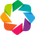

In [3]:
from pathlib import Path
import pandas as pd
from echopop.graphics import diagnostics
from echopop.utils import feat_functions, feat_parameters

# Initialize the plotting class
dplot = diagnostics.Diagnostics()

In [4]:
import panel as pn

# Define specific mesh-region-cropping function
# ---- Latitude resolution
LATITUDE_RESOLUTION = 1.25/60.
# ---- Cropping function
CROP_FUN = feat_functions.transect_ends_crop
# ---- Transect-mesh-region mapper
TRANSECT_MESH_REGION_FUN = feat_parameters.transect_mesh_region_2015
#print df_nasc_procc:\rthomas\Projects\EchoPop_validation\comparisons\cross_year_comparisons\cross_year_comparisons_20260625.png

# Transect mesh region assignment
# 'df_nasc_noage1_prt' -> Age-2+ NASC DataFrame 
mesh_cropped, transect_regions = CROP_FUN(
    #df_nasc_noage1_prt, df_mesh, LATITUDE_RESOLUTION, TRANSECT_MESH_REGION_FUN
    df_nasc_proc, df_mesh, LATITUDE_RESOLUTION, TRANSECT_MESH_REGION_FUN
)

# Check mesh cropping
dplot.plot_mesh_cropping(df_mesh, mesh_cropped, df_isobath).opts(width=650, height=400)


:Overlay
   .WMTS.I                     :WMTS   [Longitude,Latitude]
   .Points.Mesh_points         :Points   [Longitude,Latitude]
   .Points.Cropped_mesh_points :Points   [Longitude,Latitude]
   .Path.A_200m_isobath        :Path   [Longitude,Latitude]

In [5]:
# Plot the assignment
dplot.plot_transect_mesh_regions(transect_regions, mesh_cropped).opts(width=650, height=400)

:Overlay
   .WMTS.I             :WMTS   [Longitude,Latitude]
   .Points.Mesh_points :Points   [Longitude,Latitude]
   .NdOverlay.I        :NdOverlay   [mesh_region]
      :Path   [Longitude,Latitude]
   .Labels.I           :Labels   [x,y]   (labels)

In [6]:
# 'Extreme' NASC plot 
dplot.plot_nasc_map(df_nasc_proc).opts(width=650, height=400)

:Overlay
   .WMTS.I              :WMTS   [Longitude,Latitude]
   .Path.Transect_lines :Path   [Longitude,Latitude]
   .Points.I            :Points   [Longitude,Latitude]   (nasc_scaled)
   .Points.II           :Points   [Longitude,Latitude]   (transect_num,nasc,nasc_scaled,nasc_size)

In [7]:
# Plot stratified results -- biomass per stratum and overall survey
dplot.plot_stratified_results(
    stratum_results={"Transect": df_jh_transect_results, "Kriged": df_jh_kriged_results}
).opts(width=650, height=400)

:Overlay
   .NdOverlay.Confidence_intervals :NdOverlay   [agg_type]
      :ErrorBars   [x_plot]   (mean,lower,upper)
   .Points.I                       :Points   [x_plot,mean]   (rbias,agg_type)
   .Points.II                      :Points   [x_plot,mean]   (agg_type)
   .Points.III                     :Points   [x,y]   (agg_type,lower,mean,upper)